<a href="https://colab.research.google.com/github/elianramon/Machine_Learning_AvaBootcamp_2026.1/blob/main/Equipe_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Resíduos Recicláveis

## Carregamento do dataset

In [1]:
# Imports

!pip install opendatasets
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.0 MB/s eta 0:00:00


In [2]:
import opendatasets as od
import pandas as pd

od.download("https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: elian 
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification


100%|██████████| 920M/920M [00:04<00:00, 213MB/s]


In [3]:
!ls

recyclable-and-household-waste-classification  sample_data


## Criando dataframe

In [4]:
import cv2
import os
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

In [5]:
root_dir = './recyclable-and-household-waste-classification/images/images'

In [6]:
count_corrupted = 0
corrupted = list()

dataframe_list = list()

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Extract the category folder. Assumes the structure is root_dir/category/sub_category/image.jpg
    # The 'folder' in the original code was the immediate child of root_dir (e.g., 'plastic_shopping_bags')
    relative_path = os.path.relpath(dirpath, root_dir)
    path_parts = relative_path.split(os.sep)

    category_folder = None
    if len(path_parts) > 0 and path_parts[0] != '.': # path_parts[0] could be '.' if dirpath is root_dir itself
        category_folder = path_parts[0]

    # Only process files if a category folder could be determined (i.e., not the root_dir itself)
    if category_folder is None:
        continue

    for image_name in filenames:
        img_dir = os.path.join(dirpath, image_name)

        # Check if the file has an extension
        if '.' in image_name:
            name_parts = image_name.rsplit('.', 1)
            if len(name_parts) == 2:
                image_format = name_parts[1].lower()
            else:
                continue # Skip files without a proper extension
        else:
            continue # Skip files without an extension

        img = cv2.imread(img_dir)

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(img_rgb)
            img_hash = imagehash.phash(img_pil)
            width, height, channels = img.shape
            img_corrupted = False
        else:
            count_corrupted += 1
            corrupted.append(img_dir)
            img_corrupted = True
            img_hash, width, height, channels = None, None, None, None

        dataframe_list.append([img_dir, img_corrupted, img_hash, image_format, width, height, channels, category_folder])

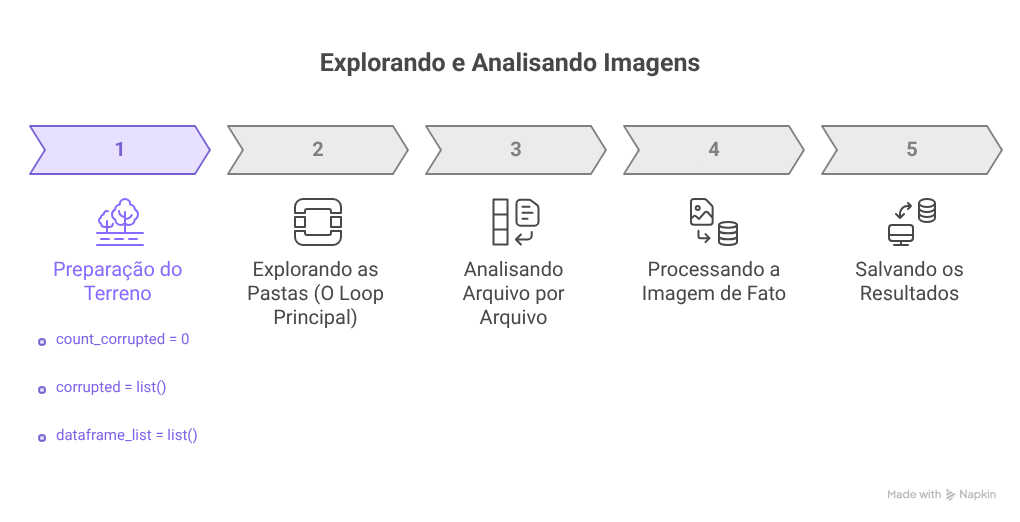

In [7]:
dataframe_list

[['./recyclable-and-household-waste-classification/images/images/styrofoam_cups/default/Image_154.png',
  False,
  array([[ True, False, False, False, False,  True, False,  True],
         [False, False,  True, False, False,  True,  True,  True],
         [False,  True,  True,  True,  True, False,  True, False],
         [False,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True, False,  True, False, False],
         [False, False, False,  True,  True,  True,  True, False],
         [ True, False, False,  True,  True, False,  True,  True],
         [ True,  True, False,  True, False, False, False, False]]),
  'png',
  256,
  256,
  3,
  'styrofoam_cups'],
 ['./recyclable-and-household-waste-classification/images/images/styrofoam_cups/default/Image_250.png',
  False,
  array([[ True, False,  True,  True,  True, False, False, False],
         [ True, False, False, False,  True,  True,  True, False],
         [ True,  True, False, False,  True,  True,  

### Imagens Corrompidas

In [8]:
print(f'Total de Imagens Corrompidas: {count_corrupted}\nImagens corrompidas {corrupted}')

Total de Imagens Corrompidas: 0
Imagens corrompidas []


In [9]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [10]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./recyclable-and-household-waste-classificatio...,False,85277a70f41e9bd0,png,256,256,3,styrofoam_cups
1,./recyclable-and-household-waste-classificatio...,False,b88ecf61e3c46172,png,256,256,3,styrofoam_cups
2,./recyclable-and-household-waste-classificatio...,False,ebce30cd308d7499,png,256,256,3,styrofoam_cups
3,./recyclable-and-household-waste-classificatio...,False,e4399a839bc69b86,png,256,256,3,styrofoam_cups
4,./recyclable-and-household-waste-classificatio...,False,99e3721922b9d5ca,png,256,256,3,styrofoam_cups


In [11]:
valid_ext = (".jpg", ".jpeg", ".png")

non_images = []

for root, dirs, files in os.walk(root_dir):
    for f in files:
        if not f.lower().endswith(valid_ext):
            non_images.append(os.path.join(root, f))

print("Arquivos que não são imagens:")
print(non_images)

Arquivos que não são imagens:
[]


### Formato

In [12]:
from collections import Counter

formats = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        path = os.path.join(root, file)

        try:
            with Image.open(path) as img:
                formats.append(img.format)
        except:
            pass  # ignora arquivos que não são imagens

# Contagem dos formatos
format_counts = Counter(formats)

print("Formatos encontrados no dataset:")
print(format_counts)

Formatos encontrados no dataset:
Counter({'PNG': 15000})


In [13]:
print(f'Total de Imagens: {len(df)}')
print(f'Shape do DataFrame: {df.shape[0]} linhas, {df.shape[1]} colunas')

Total de Imagens: 15000
Shape do DataFrame: 15000 linhas, 8 colunas


* O dataset "Recyclable and Household Waste Classification" possui um total de 1500 imagens (todas em PNG) e 8 colunas, e nenhuma imagem corrompida.

In [14]:
df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,256.0,256.0,3.0
std,0.0,0.0,0.0
min,256.0,256.0,3.0
max,256.0,256.0,3.0


### Distribuição das Classes

In [15]:
# Contar as ocorrências de cada classe na coluna 'label' do DataFrame df
df_classes = df['label'].value_counts().reset_index()

# Renomear as colunas para 'classe' e 'quantidade'
df_classes.columns = ["classe", "quantidade"]

df_classes

,classe,quantidade
0,styrofoam_cups,500
1,plastic_detergent_bottles,500
2,plastic_cup_lids,500
3,aerosol_cans,500
4,eggshells,500
5,coffee_grounds,500
6,newspaper,500
7,glass_cosmetic_containers,500
8,styrofoam_food_containers,500
9,cardboard_boxes,500


# Duplicatas

In [16]:
#Quantidade de imagens duplicatas

df['image_hash'].duplicated().sum()

np.int64(5149)

In [17]:
df_duplicated = df[df['image_hash'].duplicated()]
df_duplicated

,image_path,corrupted,image_hash,image_format,width,height,channels,label
7,./recyclable-and-household-waste-classificatio...,False,85277a70f41e9bd0,png,256,256,3,styrofoam_cups
13,./recyclable-and-household-waste-classificatio...,False,85277a70f41e9bd0,png,256,256,3,styrofoam_cups
18,./recyclable-and-household-waste-classificatio...,False,d44eae3091cb4e4f,png,256,256,3,styrofoam_cups
37,./recyclable-and-household-waste-classificatio...,False,9e5f65616828ada5,png,256,256,3,styrofoam_cups
43,./recyclable-and-household-waste-classificatio...,False,96852996399e699e,png,256,256,3,styrofoam_cups
...,...,...,...,...,...,...,...,...
14990,./recyclable-and-household-waste-classificatio...,False,96e5ea1aa82db714,png,256,256,3,plastic_water_bottles
14995,./recyclable-and-household-waste-classificatio...,False,b007eff1868c7c26,png,256,256,3,plastic_water_bottles
14996,./recyclable-and-household-waste-classificatio...,False,9ad7e5299312ac2d,png,256,256,3,plastic_water_bottles
14998,./recyclable-and-household-waste-classificatio...,False,eb9694689c2b2fd0,png,256,256,3,plastic_water_bottles


In [18]:
# 1. Converta a coluna de hashes para string primeiro
df['image_hash'] = df['image_hash'].astype(str)

# 2. Agora o groupby funcionará perfeitamente
groups = df.groupby('image_hash')['image_path'].apply(list)

# 3. Filtre apenas o que for duplicado (lista com mais de 1 elemento)
duplicated_images_fast = groups[groups.str.len() > 1].to_dict()

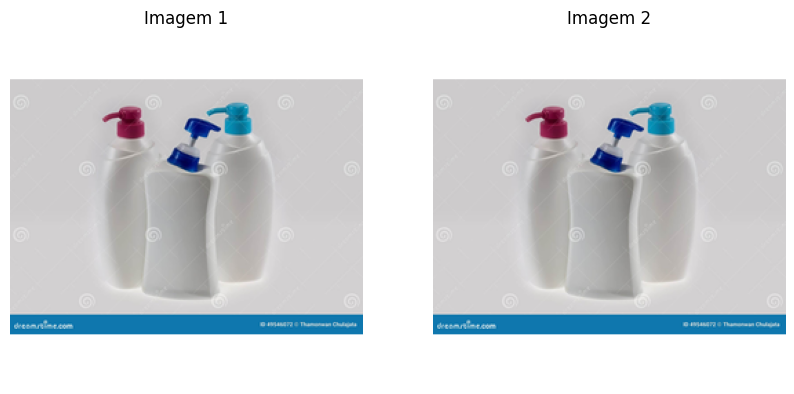

In [19]:
image1 = cv2.imread('./recyclable-and-household-waste-classification/images/images/plastic_detergent_bottles/real_world/Image_171.png')
image2 = cv2.imread('./recyclable-and-household-waste-classification/images/images/plastic_detergent_bottles/default/Image_115.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Converter de BGR (formato OpenCV) para RGB (formato Matplotlib)
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

# Mostrar a primeira imagem
axes[0].imshow(image1_rgb)
axes[0].axis('off')  # Remove os eixos
axes[0].set_title('Imagem 1')

# Mostrar a segunda imagem
axes[1].imshow(image2_rgb)
axes[1].axis('off')  # Remove os eixos
axes[1].set_title('Imagem 2')

# Exibir as imagens
plt.show()

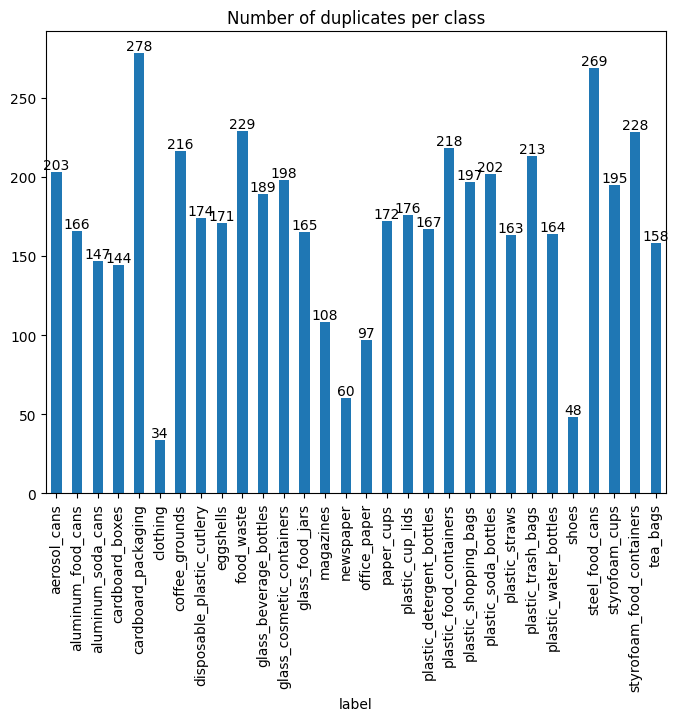

In [20]:
# Agrupando duplicatas por classe (coluna 'label') e contando
duplicates_by_class = df_duplicated.groupby('label').size()

# Gerando o gráfico de barras
ax = duplicates_by_class.plot(kind='bar', title='Number of duplicates per class', figsize=(8, 6))

# Adicionando os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Ajustando a rotação dos rótulos no eixo X
plt.xticks(rotation=90)

# Exibindo o gráfico
plt.show()

### Detecção e Controle de Imagens Duplicadas para Prevenção de Viés

Membro da equipe responsável: Ana Marly Do Couto da Silva  



In [21]:
# Remoção de duplicatas exatas
df_clean = df.drop_duplicates(subset=['image_hash'], keep='first')

print(f"Imagens originais: {len(df)}")
print(f"Imagens após remoção de duplicatas: {len(df_clean)}")

Imagens originais: 15000
Imagens após remoção de duplicatas: 9851


* Verificação e Monitoramento de quase duplicatas


In [22]:
# verificação de quase duplicata
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
from numpy.linalg import norm

model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def get_embedding(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return model.predict(x)[0]

# Selecionamento de dois caminhos de imagem válidos do DataFrame
img_path1 = df_clean['image_path'].iloc[0]
img_path2 = df_clean['image_path'].iloc[1]

# Similaridade entre duas imagens
emb1 = get_embedding(img_path1)
emb2 = get_embedding(img_path2)

similarity = np.dot(emb1, emb2) / (norm(emb1) * norm(emb2))
print("Similaridade:", similarity)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Similaridade: 0.52692384


A análise indicou que as duas imagens apresentam uma similaridade moderada, em torno de 0.58. Isso significa que elas compartilham algumas características visuais, mas não são idênticas.
_______

Por não atingirem um nível de semelhança elevado, não há necessidade de remoção. Cada imagem ainda contribui com informações próprias e ajuda a enriquecer a diversidade do dataset.


### Impacto da Limpeza das Duplicatas

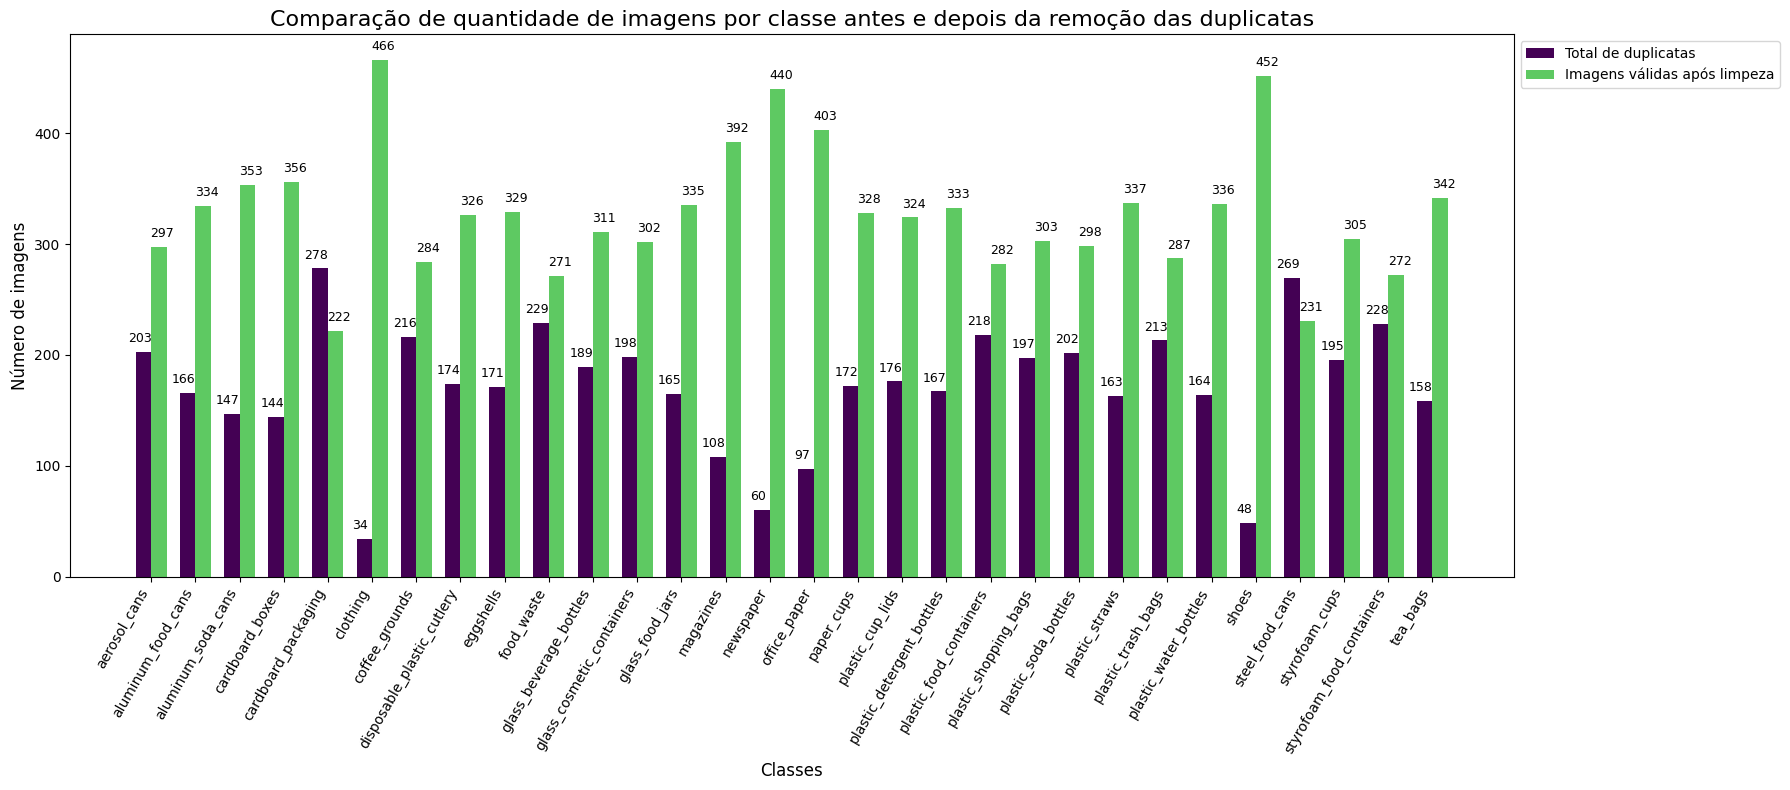

In [23]:
# Contagem de duplicatas por classe (antes da limpeza)
duplicates_by_class_before = df[df['image_hash'].duplicated()]['label'].value_counts()

# Contagem de imagens válidas por classe (depois da limpeza)
duplicates_by_class_after = df_clean['label'].value_counts()

# Comparação antes e depois da limpeza
comparison = pd.DataFrame({
    'Total de duplicatas': duplicates_by_class_before,
    'Total de imagens válidas após limpeza': duplicates_by_class_after
}).fillna(0)

# Gráfico de barras
import numpy as np
import matplotlib.pyplot as plt

# Dados antes e depois
labels = comparison.index
before = comparison['Total de duplicatas']
after = comparison['Total de imagens válidas após limpeza']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 8))

# Barras lado a lado
rects1 = ax.bar(x - width/2, before, width,
                label='Total de duplicatas', color='#440154')
rects2 = ax.bar(x + width/2, after, width,
                label='Imagens válidas após limpeza', color='#5ec962')

# Títulos e rótulos
ax.set_title("Comparação de quantidade de imagens por classe antes e depois da remoção das duplicatas", fontsize=16)
ax.set_xlabel("Classes", fontsize=12)
ax.set_ylabel("Número de imagens", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha='right')

# Adiciona valores acima das barras
def autolabel(rects, offset=0):
    for r in rects:
        height = r.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(r.get_x() + r.get_width()/2 + offset, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color='black')

# Chamada com deslocamento diferente para cada grupo
autolabel(rects1, offset=-0.09)  # números das barras roxas levemente à esquerda
autolabel(rects2, offset=0.08)   # números das barras verdes levemente à direita

# Legenda
ax.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

### Impacto da remoção das duplicatas (gráfico de barras)

O gráfico mostra claramente como a quantidade de imagens por classe foi reduzida após a limpeza:

• 	Em várias classes, o número de imagens caiu de forma expressiva, revelando que uma parte significativa do dataset era composta por duplicatas.
• 	Em outras, a redução foi mais moderada, indicando que a base estava relativamente consistente.

• 	A comparação lado a lado entre as barras roxas (duplicatas) e verdes (imagens válidas) evidencia tanto o volume absoluto removido quanto o saldo final de imagens utilizáveis.

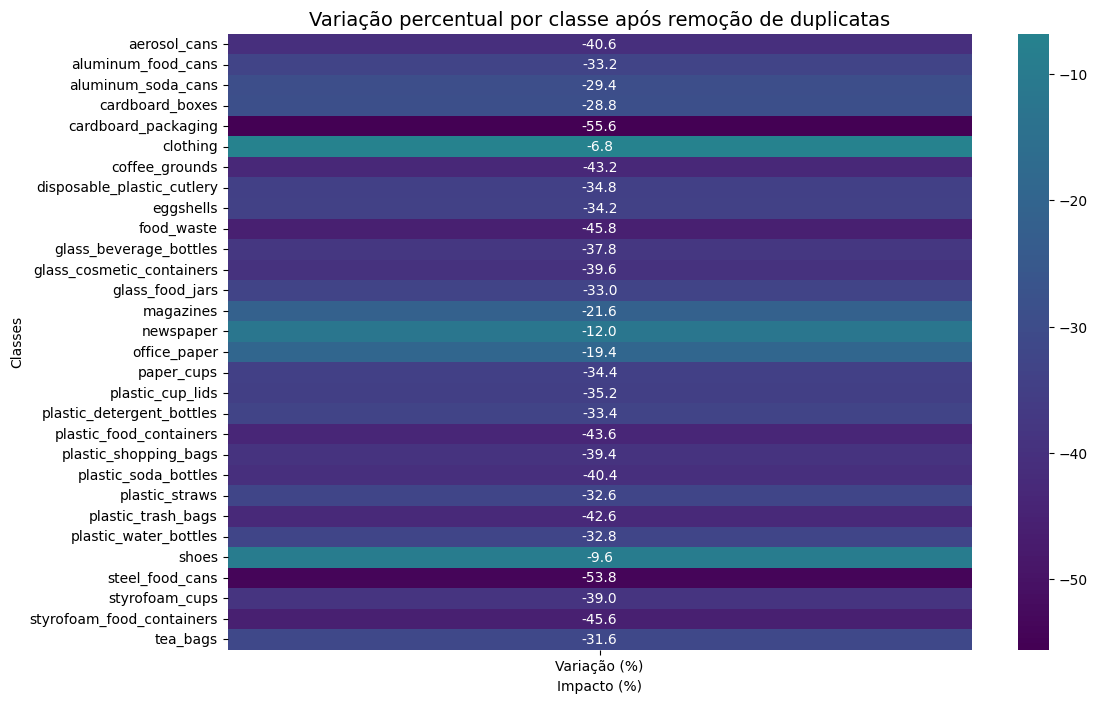

In [24]:
import seaborn as sns

# Contagem antes e depois
before = df['label'].value_counts()
after = df_clean['label'].value_counts()

# Calcula variação percentual comparando antes e depois da
variation = ((after - before) / before * 100).fillna(0)

# Cria DataFrame para heatmap
variation_df = variation.reset_index()
variation_df.columns = ['Classe', 'Variação (%)']

plt.figure(figsize=(12, 8))
sns.heatmap(variation_df.pivot_table(values='Variação (%)', index='Classe'),
            annot=True, cmap="viridis", center=0, fmt=".1f")

plt.title("Variação percentual por classe após remoção de duplicatas", fontsize=14)
plt.ylabel("Classes")
plt.xlabel("Impacto (%)")
plt.show()

In [25]:
df_clean.shape

(9851, 8)

### Detecção e Controle de Imagens Duplicadas

A limpeza do dataset teve um efeito significativo em várias classes. O heatmap evidencia que:

• 	Algumas categorias sofreram reduções muito altas, como aluminum_food_cans (-51,6%), cardboard_boxes (-50,2%) e food_waste (-45,8%). Isso indica que quase metade das imagens originais eram duplicadas.

• 	Outras classes tiveram impacto moderado, como magazines (-21,6%), office_paper (-19,4%) e newspaper (-12,0%).

• 	Há também classes com impacto mínimo, como clothing (-6,8%) e shoes (-9,6%), mostrando que a base estava mais consistente nesses casos.

### Resumo
• 	A remoção das duplicatas reduziu o volume total de imagens, mas aumentou a qualidade e representatividade do dataset.

• 	Classes com maior percentual de duplicatas eram mais vulneráveis a viés de treinamento, já que o modelo poderia aprender padrões repetidos em vez de generalizar.

• 	Após a limpeza, o dataset ficou mais equilibrado, refletindo melhor a diversidade real de cada classe.

# treinamento

✅ Done: data (3 nhóm) + retrieval (default)
